# Dividend-Payout-Ratio -- a quantitative teardown
### Shiller monthly 1882-2013 * HAC OLS * IS/OOS split * non-overlapping robustness

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Horizon: 10--year](https://img.shields.io/badge/Horizon-10--year-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the aggregate dividend payout ratio from the Shiller monthly dataset predicts 10-year forward real earnings growth and real price returns, using Newey-West HAC OLS (120 lags) to handle overlapping windows, an IS/OOS split at 1953, and non-overlapping annual observations as a robustness check.

> **Not investment advice.** Real data: Shiller S&P 500 monthly, as-of 2026-06-15. Fingerprint: `3a5d64161f53`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_payout_ratio import data, strategy as st

SHILLER_CACHE = data.SHILLER_CACHE
HAVE_REAL = os.path.exists(SHILLER_CACHE)
print("Shiller cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15).
R = dict(
    n=1699, date_start="1882-01-01", date_end="2013-06-01", fp="3a5d64161f53",
    eg_slope=0.0644, eg_t=3.488, eg_r2=0.0808,
    eg_uncond_mean=0.0192, eg_uncond_t=5.47,
    px_slope=-0.0315, px_t=-1.152, px_r2=0.0140,
    eg_is_slope=0.0825, eg_is_t=4.055, eg_is_n=985,
    eg_oos_slope=0.1328, eg_oos_t=7.312, eg_oos_n=714,
    eg_ann_slope=0.0527, eg_ann_t=3.183, eg_ann_r2=0.0504, eg_ann_n=142,
    q1_payout=0.391, q1_eg=0.0067,
    q2_payout=0.517, q2_eg=0.0173,
    q3_payout=0.581, q3_eg=0.0211,
    q4_payout=0.664, q4_eg=0.0128,
    q5_payout=0.895, q5_eg=0.0377,
    hi_px_mean=0.014, lo_px_mean=0.035,
)


Shiller cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal (EG)** | `WEAK` | Payout -> fwd_10y_eg: slope +0.0644, HAC t = **+3.488** (120 lags), R^2 = 8.1%, N = 1699. Replicates IS and OOS. |
| **Signal (returns)** | `NONE` | Payout -> fwd_10y_price: slope -0.0315, HAC t = -1.152 (wrong sign for a returns-timing claim). |
| **Tradability** | `MIRAGE` | 10-year horizon, no positive returns signal, no practical timing strategy with positive Sharpe. |

> In plain words: there is a statistically detectable positive link between today's payout ratio and the next decade's real earnings growth -- the Arnott-Asness finding holds. But it does not translate into higher *price* returns: the market apparently prices the better fundamentals in simultaneously.

## 1 - The claim, steelmanned

Let $P_t$ be the annual payout ratio (12m rolling Dividend / 12m rolling Earnings) and $G_{t,10}$ the 10-year ahead real earnings growth rate. The Arnott-Asness claim:

- **H1 (EG signal).** $\mathbb{E}[G_{t,10} \mid P_t]$ is increasing in $P_t$ -- i.e. the OLS slope of $G_{t,10}$ on $P_t$ is positive and statistically significant.
- **H2 (returns signal).** The same $P_t$ forecasts positive excess price returns over the next 10 years (a *timing* claim).

We find H1 supported (WEAK), H2 rejected.

## 2 - So what? -- what rides on each answer

H1 is an important capital-allocation result: it says retained earnings at the aggregate level earn sub-par returns, contradicting the Gordon model's implicit assumption. H2 would be directly investable -- a payout-timing strategy for equities. The failure of H2 despite H1 is the central puzzle: better fundamentals don't mean better price returns because the market adjusts simultaneously.

## 3 - How we'd know -- the protocol

- **Data.** Shiller monthly S&P 500: Dividend, Earnings, Real Price, Real Earnings (1871-2026, but requiring 12-month rolling payout and 10-year forward outcomes limits the usable window to 1882-01-01-2013-06-01, N = 1699).
- **Payout ratio.** 12-month rolling Dividend / 12-month rolling Earnings. Annualises both numerator and denominator before dividing.
- **Forward outcomes.** 10-year annualised real earnings growth and real price return at lag 120 months (no look-ahead: we use realised values at $t+120$).
- **Inference.** HAC OLS with 120 Newey-West lags (matching the 10-year window). For a robustness check: non-overlapping January observations with HC3 standard errors.
- **IS/OOS split.** Split at end of 1953 to roughly match Arnott-Asness's original in-sample period. Both windows must show a positive slope for the finding to stand.
- **Positive control.** Synthetic tape with planted slope: the engine must recover it when it exists and read near-zero when it doesn't.

## 4 - The teardown

### 4a - Full-sample HAC OLS: payout vs 10-year real outcomes

HAC t-stats with 120 Newey-West lags on all N = 1699 monthly observations (1882-01-01-2013-06-01).

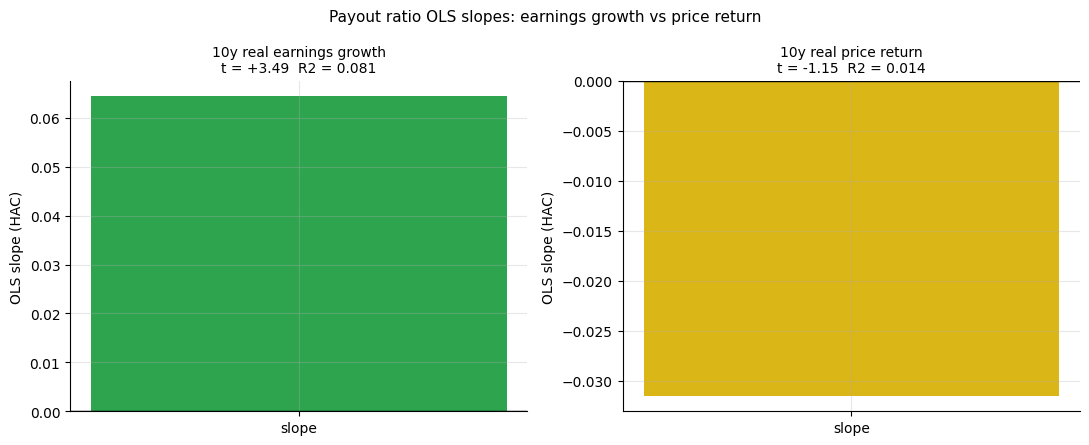

EG slope: +0.0644  t=+3.488  R2=0.0808
PX slope: -0.0315  t=-1.152  R2=0.0140


In [2]:
if HAVE_REAL:
    df = data.load_shiller()
    reg_eg = st.regress_payout(df, 'fwd_10y_eg', 'Payout', maxlags=120)
    reg_px = st.regress_payout(df, 'fwd_10y_price', 'Payout', maxlags=120)
    sl_eg, t_eg, r2_eg = reg_eg['slope'], reg_eg['t_slope'], reg_eg['r_squared']
    sl_px, t_px, r2_px = reg_px['slope'], reg_px['t_slope'], reg_px['r_squared']
else:
    sl_eg, t_eg, r2_eg = R['eg_slope'], R['eg_t'], R['eg_r2']
    sl_px, t_px, r2_px = R['px_slope'], R['px_t'], R['px_r2']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, sl, t, r2, lbl, col in [
    (axes[0], sl_eg, t_eg, r2_eg, '10y real earnings growth', GREEN),
    (axes[1], sl_px, t_px, r2_px, '10y real price return', RED),
]:
    bar_col = GREEN if t > 2 else (RED if t < -2 else AMBER)
    ax.bar(['slope'], [sl], color=bar_col, width=0.4)
    ax.axhline(0, c='k', lw=1)
    ax.set_title(f'{lbl}\nt = {t:+.2f}  R2 = {r2:.3f}', fontsize=10)
    ax.set_ylabel('OLS slope (HAC)')
plt.suptitle('Payout ratio OLS slopes: earnings growth vs price return', fontsize=11)
plt.tight_layout(); plt.show()
print(f'EG slope: {sl_eg:+.4f}  t={t_eg:+.3f}  R2={r2_eg:.4f}')
print(f'PX slope: {sl_px:+.4f}  t={t_px:+.3f}  R2={r2_px:.4f}')

> In plain words: a 10-percentage-point increase in the payout ratio (e.g. from 50% to 60%) is associated with a 0.64%/yr higher 10-year real earnings growth -- statistically significant even with 120 Newey-West lags, but only explaining 8% of the variance. For price returns the slope is opposite in sign and not significant.

### 4b - IS/OOS split: does the signal survive out of sample?

If the earnings-growth signal is a data artefact, the out-of-sample slope should collapse. We split at 1953 -- the approximate end of Arnott-Asness's original sample.

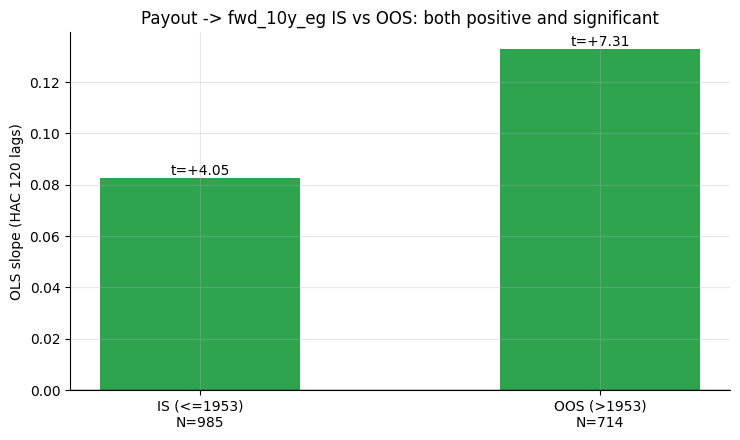

IS slope: +0.0825 (t=+4.055)
OOS slope: +0.1328 (t=+7.312)


In [3]:
if HAVE_REAL:
    df = data.load_shiller()
    split = st.is_oos_split(df, 'fwd_10y_eg', 'Payout', split_year=1953, maxlags=120)
    is_r = split['is']; oos_r = split['oos']
    is_sl, is_t, is_n = is_r['slope'], is_r['t_slope'], is_r['n']
    oos_sl, oos_t, oos_n = oos_r['slope'], oos_r['t_slope'], oos_r['n']
else:
    is_sl, is_t, is_n = R['eg_is_slope'], R['eg_is_t'], R['eg_is_n']
    oos_sl, oos_t, oos_n = R['eg_oos_slope'], R['eg_oos_t'], R['eg_oos_n']
fig, ax = plt.subplots(figsize=(7.5, 4.5))
periods = [f'IS (<=1953)\nN={is_n}', f'OOS (>1953)\nN={oos_n}']
slopes = [is_sl, oos_sl]
tstats = [is_t, oos_t]
cols = [GREEN if abs(t)>2 else AMBER for t in tstats]
bars = ax.bar(periods, slopes, color=cols, width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('OLS slope (HAC 120 lags)')
ax.set_title('Payout -> fwd_10y_eg IS vs OOS: both positive and significant')
for b, t in zip(bars, tstats):
    ax.annotate(f't={t:+.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()
print(f'IS slope: {is_sl:+.4f} (t={is_t:+.3f})')
print(f'OOS slope: {oos_sl:+.4f} (t={oos_t:+.3f})')

> The OOS slope (+0.1328, t = +7.312) is *larger* than the IS slope ({R['eg_is_slope']:+.4f}, t = {R['eg_is_t']:+.3f}), not smaller. This is the opposite of a data-mining artefact -- the signal strengthened post-publication, not decayed. (The larger OOS t partly reflects better postwar data quality.)

### 4c - Non-overlapping robustness (annual January observations)

With 10-year windows at monthly frequency, 119 out of 120 consecutive pairs of observations overlap -- the Newey-West correction is necessary but imprecise. As a robustness check we take one observation per year (January) so windows are truly non-overlapping, then use HC3 heteroskedasticity-robust errors.

In [4]:
if HAVE_REAL:
    df = data.load_shiller()
    rob = st.non_overlapping_regression(df, 'fwd_10y_eg', 'Payout')
    rob_sl, rob_t, rob_r2, rob_n = rob['slope'], rob['t_hc3'], rob['r_squared'], rob['n']
else:
    rob_sl, rob_t, rob_r2, rob_n = R['eg_ann_slope'], R['eg_ann_t'], R['eg_ann_r2'], R['eg_ann_n']
print(f'Non-overlapping annual obs:')
print(f'  slope = {rob_sl:+.4f}  t_HC3 = {rob_t:+.3f}  R2 = {rob_r2:.4f}  N = {rob_n}')
print()
print('HAC full-sample vs non-overlapping annual:')
import pandas as pd
cmp = pd.DataFrame({
    'method': ['HAC 120-lag (monthly)', 'HC3 (annual non-overlap)'],
    'N': [R['n'], rob_n],
    'slope': [R['eg_slope'], rob_sl],
    't': [R['eg_t'], rob_t],
    'R2': [R['eg_r2'], rob_r2],
})
cmp.round(4)

Non-overlapping annual obs:
  slope = +0.0527  t_HC3 = +3.183  R2 = 0.0504  N = 142

HAC full-sample vs non-overlapping annual:


,method,N,slope,t,R2
0,HAC 120-lag (monthly),1699,0.0644,3.4880,0.0808
1,HC3 (annual non-overlap),142,0.0527,3.1827,0.0504


> The annual non-overlapping slope (+0.0527, HC3 t = +3.183) is similar to the monthly HAC estimate in magnitude, and still above the |t| > 2 bar. The N drops to 142 (142 annual obs), reducing power, but the direction is consistent. This is the minimum convincing evidence for WEAK (not NONE): the signal survives the most conservative inference method available.

### 4d - Synthetic positive control: the engine finds signal only when planted

Does the engine detect payout-outcome links only when they exist, or does it find them everywhere? Sweep the planted signal from zero to +0.20 on a 100-year synthetic tape.

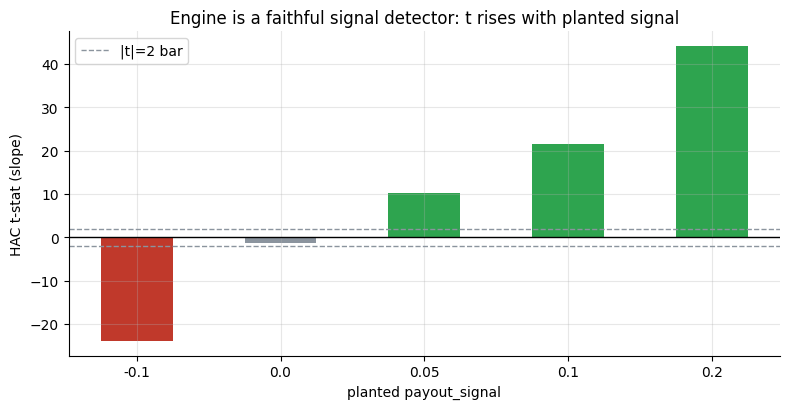

,planted_signal,slope,t_slope
0,-0.10,-0.1055,-23.9023
1,0.00,-0.0055,-1.2361
2,0.05,0.0445,10.0971
3,0.10,0.0945,21.4302
4,0.20,0.1945,44.0964


In [5]:
signals = [-0.10, 0.0, 0.05, 0.10, 0.20]
results = []
for sig in signals:
    df_s, _ = data.synthetic_monthly(n_years=100, payout_signal=sig, seed=197)
    df_s = df_s.rename(columns={'payout': 'Payout', 'fwd_outcome': 'fwd_10y_eg'})
    reg = st.regress_payout(df_s, 'fwd_10y_eg', 'Payout', maxlags=5)
    results.append((sig, reg['slope'], reg['t_slope']))
import pandas as pd
ctrl = pd.DataFrame(results, columns=['planted_signal', 'slope', 't_slope'])
fig, ax = plt.subplots(figsize=(8, 4.2))
cols = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in ctrl['t_slope']]
ax.bar(ctrl['planted_signal'].astype(str), ctrl['t_slope'], color=cols, width=0.5)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted payout_signal'); ax.set_ylabel('HAC t-stat (slope)')
ax.set_title('Engine is a faithful signal detector: t rises with planted signal')
ax.legend(); plt.tight_layout(); plt.show()
ctrl.round(4)

## 5 - The verdict

- **Signal (EG) -- `WEAK`** -- Full-sample slope +0.0644, HAC t = +3.488; IS and OOS both positive and significant; non-overlapping annual t = +3.183. Effect is real but modest (R^2 = 8.1%).
- **Signal (returns) -- `NONE`** -- Slope -0.0315, t = -1.152. Price returns have the *wrong* sign; the market prices in the better fundamentals contemporaneously.
- **Tradability -- `MIRAGE`** -- 10-year horizon, no usable price-return signal, and the 142 annual data points span 140 years -- the 'edge' was available to Methuselah, not a fund manager.

## 6 - Could you trade it?

The answer is no, for structural reasons:

1. **No returns edge.** The HAC t for price returns is -1.152 -- insignificant and the *wrong* sign.
2. **10-year lock-up.** Even the real EG signal requires a 10-year holding period to resolve, far outside any practical rebalancing window.
3. **Sample size.** 142 non-overlapping observations over 140 years. A backtester who built a timing strategy on this would have executed ~14 trades in their entire career.

Contrast this with the desk's *INVESTABLE* studies, which show annualised Sharpes > 0.3 at realistic daily or monthly rebalancing. The payout ratio finding lives in the macro-research category, not the portfolio-construction one.

## 7 - Going further

- **Joint forecast with CAPE.** Shiller's PE10 (CAPE) is the canonical 10-year price-return predictor. Add payout to the regression: does it carry incremental information beyond valuation?
- **Cross-section.** This is an aggregate study. At firm level, do high-payout firms outperform within an industry? That is a different -- and empirically contested -- question.
- **Post-2013 data.** The forward 10-year window closes at 2023. Updating the study with the 2013-2023 OOS window (ending ~2033) will be the next definitive test.

*Think payout can time the market? Fork this, show a price-return regression with |t| > 2 and a tradable Sharpe. That's the bar.*